# Damages by country - LitPop data

This notebook computes damages, by merging LitPop data and cyclone tracks and using the damage function emanuel_2011. The cyclone tracks must have the variable country (it can be added to the code output by running Add_country_to_tracks.ipynb).

## Imports

In [ ]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

import pandas as pd
from pathlib import Path
import pyarrow as pa
import pyarrow.parquet as pq
import pyarrow.dataset as ds
import pyarrow.compute as pc
import pyarrow.csv as pv
import numpy as np
import polars as pl
import geopandas as gpd
from src.damages.damage_functions import emanuel_2011
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

import tarfile
import io
import os
import gc

from scipy.spatial import cKDTree
from pyproj import Transformer
import psutil

pd.set_option('display.max_columns', 500)

## Configuration

In [ ]:
# Configuration du modèle et expérience
model = "ACCESS-CM2"
experiment = "ssp245"

# Chemins des données
tracks_dir = Path(f"../data/output/catherina/intensified_tracks_with_country/{model}/{experiment}")
litpop_tar_path = Path("../data/input/wealth_densities/litpop/litpop_full/LitPop_v1_2.tar")
output_dir = Path(f"../data/output/damages/by_country/{model}/{experiment}")

# Créer le répertoire de sortie
output_dir.mkdir(parents=True, exist_ok=True)

print(f"✓ Modèle: {model}")
print(f"✓ Expérience: {experiment}")
print(f"✓ Répertoire tracks: {tracks_dir}")
print(f"✓ Archive LitPop: {litpop_tar_path}")
print(f"✓ Répertoire sortie: {output_dir}")

✓ Modèle: ACCESS-CM2
✓ Expérience: ssp245
✓ Répertoire tracks: data/output/catherina/intensified_tracks_with_country/ACCESS-CM2/ssp245
✓ Archive LitPop: data/input/wealth_densities/litpop/litpop_full/LitPop_v1_2.tar
✓ Répertoire sortie: data/output/damages/by_country/ACCESS-CM2/ssp245


## Charger le dataset des tracks

In [7]:
# Charger le dataset partitionné des tracks
tracks_ds = ds.dataset(tracks_dir, partitioning="hive")

# Récupérer un sample pour explorer
sample = tracks_ds.head(1000).to_pandas()
print(f"Colonnes disponibles ({len(sample.columns)}):")
print(list(sample.columns))
print(f"\nFormes des données: {sample.shape}")
print(f"\nPremières lignes:")
print(sample.head())

Colonnes disponibles (57):
['SID', 'step', 'index', 'lat_left', 'lon_left', 'datetime', 'time', 'y', 'x', 'nshr', 'mslp_hpa', 'T_strat', 'SST', 'height', 'lat_right', 'lon_right', 'distance_track_env', 'thermo_eff', 'basin', 'A', 'B', 'C', 'a', 'b', 'c_0', 'c_1', 'c_2', 'c_3', 'sigma_pc', 'q_env', 'wind_speed', 'delta_pc_hpa', 'pc_hpa', 'eps_pc', 'is_on_land', 'dist2coast_meters', 'V_0', 't_L_steps', 'final_wind_speed', 'delta_pc_hpa_1', 'pc_hpa_1', 'final_wind_1', 'final_wind_2', 'V_0_1', 't_L_steps_1', 'pc_hpa_1_eff', 'qc', 'delta_Sm', 'X', 'MPI_hpa', 'mpd_hpa', 'mslp_mpd_diff_hpa', 'country', 'country_iso2', 'seed', 'year', 'month']

Formes des données: (1000, 57)

Premières lignes:
         SID  step  index   lat_left    lon_left            datetime  \
0  760516614     0      0  12.500484 -106.500000 2025-10-01 00:00:00   
1  760516614     1      1  12.461908 -106.572353 2025-10-01 03:00:00   
2  760516614     2      2  12.434372 -106.662559 2025-10-01 06:00:00   
3  760516614     

## Obtenir la liste des pays disponibles

In [8]:
# Obtenir la liste unique des pays dans les données de tracks
countries_in_tracks = pc.unique(tracks_ds.to_table(["country_iso2"]).column("country_iso2")).to_pylist()
countries_in_tracks = [c for c in countries_in_tracks if c is not None]
countries_in_tracks = sorted(countries_in_tracks)

print(f"Nombre de pays: {len(countries_in_tracks)}")
print(f"Pays: {countries_in_tracks}")

Nombre de pays: 127
Pays: ['-99', 'AE', 'AF', 'AT', 'AU', 'AZ', 'BA', 'BD', 'BE', 'BF', 'BG', 'BN', 'BR', 'BS', 'BT', 'BW', 'BZ', 'CA', 'CD', 'CF', 'CG', 'CH', 'CM', 'CN', 'CN-TW', 'CO', 'CR', 'CU', 'CZ', 'DE', 'DJ', 'DK', 'DO', 'DZ', 'EG', 'EH', 'ER', 'ES', 'ET', 'FJ', 'GB', 'GH', 'GM', 'GN', 'GR', 'GT', 'GW', 'GY', 'HN', 'HR', 'HT', 'ID', 'IE', 'IL', 'IN', 'IR', 'IT', 'JM', 'JO', 'JP', 'KE', 'KH', 'KP', 'KR', 'KZ', 'LA', 'LK', 'LR', 'LU', 'LY', 'MA', 'ME', 'MG', 'MK', 'ML', 'MM', 'MN', 'MR', 'MW', 'MX', 'MY', 'MZ', 'NA', 'NC', 'NE', 'NG', 'NI', 'NL', 'NP', 'NZ', 'OM', 'PA', 'PG', 'PH', 'PK', 'PR', 'PT', 'RO', 'RS', 'RU', 'SA', 'SB', 'SD', 'SI', 'SN', 'SO', 'SR', 'SS', 'SV', 'SZ', 'TD', 'TG', 'TH', 'TJ', 'TL', 'TM', 'TT', 'TZ', 'US', 'UZ', 'VE', 'VN', 'VU', 'YE', 'ZA', 'ZM', 'ZW']


## Explorer l'archive LitPop

In [9]:
# Lister les fichiers dans l'archive LitPop
litpop_files = {}

with tarfile.open(litpop_tar_path, "r") as tar:
    for member in tar:
        if member.isfile():
            filename = member.name
            # Extraire le code pays ISO3 du nom du fichier
            if "LitPop_pc_30arcsec_" in filename:
                iso3 = filename.split("_")[-1].split(".")[0]
                litpop_files[iso3] = filename

print(f"Nombre de pays dans LitPop: {len(litpop_files)}")
print(f"Exemples: {list(litpop_files.items())[:5]}")

Nombre de pays dans LitPop: 224
Exemples: [('LTU', 'LitPop_v1_2/LitPop_pc_30arcsec_LTU.csv'), ('BWA', 'LitPop_v1_2/LitPop_pc_30arcsec_BWA.csv'), ('IRQ', 'LitPop_v1_2/LitPop_pc_30arcsec_IRQ.csv'), ('MHL', 'LitPop_v1_2/LitPop_pc_30arcsec_MHL.csv'), ('SVN', 'LitPop_v1_2/LitPop_pc_30arcsec_SVN.csv')]


## Mapping ISO3 <-> ISO2

In [10]:
# Créer un mapping entre ISO3 et ISO2
# En utilisant geopandas qui a les données des pays
countries_geodf = gpd.read_file(
    "https://naciscdn.org/naturalearth/10m/cultural/ne_10m_admin_0_countries.zip"
)

# Créer le dictionnaire ISO3 -> ISO2
iso3_to_iso2 = dict(zip(
    countries_geodf["ADM0_A3"],
    countries_geodf["ISO_A2"]
))

print(f"Exemple de mapping: USA -> {iso3_to_iso2.get('USA')}")
print(f"Exemple de mapping: GBR -> {iso3_to_iso2.get('GBR')}")

Exemple de mapping: USA -> US
Exemple de mapping: GBR -> GB


## Fonction pour charger LitPop par pays

In [4]:
def load_litpop_country(iso3_code, litpop_tar_path):
    """
    Charge les données LitPop pour un pays donné depuis le fichier tar.
    
    Parameters:
    -----------
    iso3_code : str
        Code ISO3 du pays (ex: "USA", "GBR")
    litpop_tar_path : Path
        Chemin vers l'archive LitPop
    
    Returns:
    --------
    pd.DataFrame
        DataFrame avec colonnes: lon, lat, value
    """
    file_path = f"LitPop_v1_2/LitPop_pc_30arcsec_{iso3_code}.csv"
    
    with tarfile.open(litpop_tar_path, "r:") as tar:
        try:
            member = tar.getmember(file_path)
            f = tar.extractfile(member)
            
            # Lire le CSV avec pyarrow en streaming pour limiter la mémoire
            csv_reader = pv.open_csv(
                f,
                read_options=pv.ReadOptions(block_size=1 << 20),
            )
            table = csv_reader.read_all()
            df = table.to_pandas()
            
            # Renommer les colonnes pour la cohérence
            if len(df.columns) >= 4:
                df.columns = ["value", "lat", "lon", "region_id"] + list(df.columns[4:])
            else:
                df.columns = ["value", "lat", "lon", "region_id"]
            
            return df
        except KeyError:
            print(f"Avertissement: {iso3_code} non trouvé dans l'archive")
            return None


# Test
# Ce test permet de vérifier que la fonction peut ouvrir l'archive et lire un pays.
test_df = load_litpop_country("USA", litpop_tar_path)
if test_df is not None:
    print(f"Test USA: {test_df.shape}")
    print(test_df.head())
    print(f"Valeur totale: {test_df['value'].sum():,.0f}")

KeyboardInterrupt: 

## Fonction pour calculer les dommages par pays

In [14]:
def process_country_damages(
    iso2_code,
    iso3_code,
    tracks_ds,
    litpop_tar_path,
    output_dir,
):
    """
    Calcule les dommages pour un pays donné et les sauvegarde.
    
    Parameters:
    -----------
    iso2_code : str
        Code ISO2 du pays
    iso3_code : str
        Code ISO3 du pays (pour chercher dans LitPop)
    tracks_ds : pyarrow.dataset
        Dataset des tracks
    litpop_tar_path : Path
        Chemin vers l'archive LitPop
    output_dir : Path
        Répertoire de sortie
    """
    
    def mem():
        return psutil.Process(os.getpid()).memory_info().rss / 1e9
    
    print(f"\n{'='*60}")
    print(f"Pays: {iso2_code} ({iso3_code})")
    print(f"{'='*60}")
    print(f"[START RAM] {mem():.2f} GB")
    
    output_file = output_dir / f"{iso2_code}.parquet"
    temp_output_file = output_dir / f"{iso2_code}.parquet.tmp"
    if output_file.exists() and output_file.stat().st_size > 0:
        print(f"  ➜ Fichier déjà existant, pays ignoré : {output_file}")
        return True
    
    # Charger les données LitPop
    print(f"Chargement LitPop...")
    litpop_df = load_litpop_country(iso3_code, litpop_tar_path)
    
    if litpop_df is None or len(litpop_df) == 0:
        print(f"  ✗ Aucune donnée LitPop pour {iso2_code}")
        return False
    
    print(f"  ✓ LitPop chargé: {litpop_df.shape}")
    
    # Transformer les coordonnées en Mercator
    print(f"Projection spatiale...")
    transformer = Transformer.from_crs(
        "EPSG:4326",
        "EPSG:3857",
        always_xy=True,
    )
    
    lit_x, lit_y = transformer.transform(
        litpop_df["lon"].values,
        litpop_df["lat"].values,
    )
    lit_coords = np.column_stack((lit_x, lit_y)).astype(np.float32)
    tree = cKDTree(lit_coords)
    
    lit_val = litpop_df["value"].to_numpy(dtype=np.float32)
    lit_lon = litpop_df["lon"].to_numpy(dtype=np.float32)
    lit_lat = litpop_df["lat"].to_numpy(dtype=np.float32)
    
    print(f"  ✓ Arbre spatial créé")
    
    # Writer incrémental pour limiter la mémoire
    print(f"Fusion des données et écriture incrémentale...")
    writer = None
    n_written = 0
    batch_size = 50_000
    success = True
    
    try:
        for batch in tracks_ds.to_batches(
            filter=(ds.field("country_iso2") == iso2_code),
            batch_size=batch_size,
            columns=[
                "seed",
                "year",
                "month",
                "lat_left",
                "lon_left",
                "final_wind_speed",
            ],
        ):
            batch_df = batch.to_pandas()
            if len(batch_df) == 0:
                continue
            
            x, y = transformer.transform(
                batch_df["lon_left"].values,
                batch_df["lat_left"].values,
            )
            coords = np.column_stack((x, y)).astype(np.float32, copy=False)
            
            _, idx = tree.query(coords, k=1, workers=1)
            
            litpop_values = lit_val[idx]
            litpop_lon = lit_lon[idx]
            litpop_lat = lit_lat[idx]
            
            relative_losses = emanuel_2011(batch_df["final_wind_speed"].values)
            absolute_losses = relative_losses * litpop_values
            
            output_table = pa.table(
                {
                    "country_iso2": np.full(len(batch_df), iso2_code, dtype=object),
                    "seed": batch_df["seed"].values,
                    "year": batch_df["year"].values,
                    "month": batch_df["month"].values,
                    "track_lat": batch_df["lat_left"].values,
                    "track_lon": batch_df["lon_left"].values,
                    "litpop_lat": litpop_lat,
                    "litpop_lon": litpop_lon,
                    "final_wind_speed": batch_df["final_wind_speed"].values,
                    "litpop_value": litpop_values,
                    "relative_losses": relative_losses,
                    "absolute_losses": absolute_losses,
                }
            )
            
            if writer is None:
                writer = pq.ParquetWriter(
                    temp_output_file,
                    output_table.schema,
                    compression="zstd",
                )
            writer.write_table(output_table)
            n_written += len(batch_df)
            del batch_df, output_table, coords, idx, litpop_values, litpop_lon, litpop_lat, relative_losses, absolute_losses
            gc.collect()
    except Exception as e:
        print(f"  ✗ Erreur pendant le traitement de {iso2_code} : {e}")
        success = False
    finally:
        if writer is not None:
            writer.close()
    
    if not success or n_written == 0:
        if temp_output_file.exists():
            temp_output_file.unlink()
        if not success:
            print(f"  ✗ Échec du calcul pour {iso2_code}")
        else:
            print(f"  ✗ Aucun enregistrement écrit pour {iso2_code}")
        return False
    
    if temp_output_file.exists():
        temp_output_file.replace(output_file)
    
    print(f"  ✓ Sauvegardé: {output_file} ({n_written:,} lignes)")
    print(f"[END RAM] {mem():.2f} GB")
    
    del (
        litpop_df,
        lit_x,
        lit_y,
        lit_coords,
        tree,
        lit_val,
        lit_lon,
        lit_lat,
    )
    gc.collect()
    return True

## Traiter tous les pays

In [16]:
# Identifier les pays déjà traités et ceux qui ont échoué
import os

completed_files = [f.stem for f in output_dir.glob("*.parquet")]
failed_file_path = output_dir / "failed_countries.txt"

# Lire les pays échoués s'il existe
failed_from_previous = []
if failed_file_path.exists():
    failed_from_previous = failed_file_path.read_text().strip().split("\n")
    failed_from_previous = [c.strip() for c in failed_from_previous if c.strip()]

# Identifier les pays à traiter
already_done = set(completed_files)
still_to_do = [c for c in countries_in_tracks if c not in already_done]
needs_retry = [c for c in countries_in_tracks if c in failed_from_previous and c not in already_done]

print(f"╔{'='*60}╗")
print(f"║ DIAGNOSTIC DE PROGRESSION                              ║")
print(f"╚{'='*60}╝")
print(f"\n✓ Pays traités avec succès: {len(already_done)}")
if already_done:
    print(f"  Exemples: {', '.join(sorted(list(already_done))[:10])}")

print(f"\n✗ Pays en échec (à relancer): {len(needs_retry)}")
if needs_retry:
    print(f"  {', '.join(sorted(needs_retry))}")

print(f"\n⚠ Pays non encore traités: {len(still_to_do)}")
if still_to_do:
    print(f"  Total: {len(still_to_do)} pays")
    print(f"  Exemples: {', '.join(sorted(still_to_do)[:10])}")

print(f"\n📊 RÉSUMÉ")
print(f"  Total pays avec tracks: {len(countries_in_tracks)}")
print(f"  Complétés: {len(already_done)}")
print(f"  À faire: {len(still_to_do) + len(needs_retry)}")
print(f"  Taux de complétude: {100*len(already_done)/len(countries_in_tracks):.1f}%")
print(f"\n{'='*60}\n")

# CHOIX DE MODE
# Décommenter la ligne souhaitée pour relancer sur les pays échoués ou tous les pays restants
# countries_to_process = needs_retry  # Relancer UNIQUEMENT les pays échoués
# countries_to_process = still_to_do + needs_retry  # Tous les pays non terminés
countries_to_process = countries_in_tracks  # Tous les pays (par défaut, reprise sur fichiers existants)

print(f"Mode sélectionné: traiter {len(countries_to_process)} pays")
print(f"Les fichiers existants seront ignorés automatiquement.\n")


╔============================================================╗
║ DIAGNOSTIC DE PROGRESSION                              ║
╚============================================================╝

✓ Pays traités avec succès: 96
  Exemples: AE, AF, AT, AU, AZ, BA, BD, BE, BF, BG

✗ Pays en échec (à relancer): 0

⚠ Pays non encore traités: 31
  Total: 31 pays
  Exemples: -99, EH, LY, RU, SA, SB, SD, SI, SN, SO

📊 RÉSUMÉ
  Total pays avec tracks: 127
  Complétés: 96
  À faire: 31
  Taux de complétude: 75.6%


Mode sélectionné: traiter 127 pays
Les fichiers existants seront ignorés automatiquement.



In [17]:
# Mode de relance - DÉCOMMENTER LA LIGNE SOUHAITÉE
print("MODES DE RELANCE DISPONIBLES:")
print("1. needs_retry:     Relancer UNIQUEMENT les pays en échec")
print("2. still_to_do:     Traiter UNIQUEMENT les pays jamais tentés")
print("3. still_to_do + needs_retry:     Tous les pays non terminés")
print("4. countries_in_tracks:     Tous les pays (reprise auto si fichiers existants)")
print()

# À DÉCOMMENTER POUR CHANGER DE MODE:
# countries_to_process = needs_retry
countries_to_process = still_to_do
countries_to_process = still_to_do + needs_retry


MODES DE RELANCE DISPONIBLES:
1. needs_retry:     Relancer UNIQUEMENT les pays en échec
2. still_to_do:     Traiter UNIQUEMENT les pays jamais tentés
3. still_to_do + needs_retry:     Tous les pays non terminés
4. countries_in_tracks:     Tous les pays (reprise auto si fichiers existants)



In [ ]:
# Créer un mapping direct ISO2 -> ISO3
iso2_to_iso3 = {
    iso2: iso3
    for iso3, iso2 in iso3_to_iso2.items()
    if iso2 is not None and iso2 != ''
}

# Traiter les pays sélectionnés
failed_countries = []
completed_countries = []
for iso2_code in tqdm(countries_to_process, desc="Traitement des pays"):
    iso3_code = iso2_to_iso3.get(iso2_code)
    if iso3_code is None:
        print(f"  ✗ Code ISO3 non trouvé pour {iso2_code}")
        failed_countries.append(iso2_code)
        continue

    try:
        success = process_country_damages(
            iso2_code,
            iso3_code,
            tracks_ds,
            litpop_tar_path,
            output_dir,
        )
        if success:
            completed_countries.append(iso2_code)
        else:
            failed_countries.append(iso2_code)
    except Exception as e:
        print(f"  ✗ Erreur pour {iso2_code}: {str(e)}")
        failed_countries.append(iso2_code)

if failed_countries:
    failed_file = output_dir / "failed_countries.txt"
    failed_file.write_text("\n".join(sorted(set(failed_countries))))
    print(f"\nPays échoués sauvegardés dans: {failed_file}")

print(f"\nPays traités avec succès: {len(completed_countries)}")
print(f"Pays échoués: {len(failed_countries)}")

Traitement des pays:   0%|          | 0/31 [00:00<?, ?it/s]


Pays: -99 (SCR)
[START RAM] 19.76 GB
Chargement LitPop...
Avertissement: SCR non trouvé dans l'archive
  ✗ Aucune donnée LitPop pour -99

Pays: EH (SAH)
[START RAM] 19.76 GB
Chargement LitPop...
Avertissement: SAH non trouvé dans l'archive
  ✗ Aucune donnée LitPop pour EH

Pays: LY (LBY)
[START RAM] 19.76 GB
Chargement LitPop...
Avertissement: LBY non trouvé dans l'archive
  ✗ Aucune donnée LitPop pour LY

Pays: RU (RUS)
[START RAM] 19.76 GB
Chargement LitPop...
  ✓ LitPop chargé: (42177366, 4)
Projection spatiale...
  ✓ Arbre spatial créé
Fusion des données et écriture incrémentale...


/home/tiphanie/projets_python/catherina/src/damages/damage_functions.py:131: UserWarning: The default value for 'v_half' has not been changed. The current value was calibrated on US tropical cyclones.
  warnings.warn(
/home/tiphanie/projets_python/catherina/src/damages/damage_functions.py:131: UserWarning: The default value for 'v_half' has not been changed. The current value was calibrated on US tropical cyclones.
  warnings.warn(
/home/tiphanie/projets_python/catherina/src/damages/damage_functions.py:131: UserWarning: The default value for 'v_half' has not been changed. The current value was calibrated on US tropical cyclones.
  warnings.warn(
/home/tiphanie/projets_python/catherina/src/damages/damage_functions.py:131: UserWarning: The default value for 'v_half' has not been changed. The current value was calibrated on US tropical cyclones.
  warnings.warn(
/home/tiphanie/projets_python/catherina/src/damages/damage_functions.py:131: UserWarning: The default value for 'v_half' has not

  ✓ Sauvegardé: data/output/damages/by_country/ACCESS-CM2/ssp245/RU.parquet (7,471 lignes)
[END RAM] 22.93 GB

Pays: SA (SAU)
[START RAM] 18.67 GB
Chargement LitPop...
  ✓ LitPop chargé: (2462655, 4)
Projection spatiale...
  ✓ Arbre spatial créé
Fusion des données et écriture incrémentale...


/home/tiphanie/projets_python/catherina/src/damages/damage_functions.py:131: UserWarning: The default value for 'v_half' has not been changed. The current value was calibrated on US tropical cyclones.
  warnings.warn(
/home/tiphanie/projets_python/catherina/src/damages/damage_functions.py:131: UserWarning: The default value for 'v_half' has not been changed. The current value was calibrated on US tropical cyclones.
  warnings.warn(
/home/tiphanie/projets_python/catherina/src/damages/damage_functions.py:131: UserWarning: The default value for 'v_half' has not been changed. The current value was calibrated on US tropical cyclones.
  warnings.warn(
/home/tiphanie/projets_python/catherina/src/damages/damage_functions.py:131: UserWarning: The default value for 'v_half' has not been changed. The current value was calibrated on US tropical cyclones.
  warnings.warn(
/home/tiphanie/projets_python/catherina/src/damages/damage_functions.py:131: UserWarning: The default value for 'v_half' has not

...

  ✓ Sauvegardé: data/output/damages/by_country/ACCESS-CM2/ssp245/TM.parquet (1,638 lignes)
[END RAM] 16.47 GB

Pays: TT (TTO)
[START RAM] 16.47 GB
Chargement LitPop...
  ✓ LitPop chargé: (6099, 4)
Projection spatiale...
  ✓ Arbre spatial créé
Fusion des données et écriture incrémentale...


/home/tiphanie/projets_python/catherina/src/damages/damage_functions.py:131: UserWarning: The default value for 'v_half' has not been changed. The current value was calibrated on US tropical cyclones.
  warnings.warn(
/home/tiphanie/projets_python/catherina/src/damages/damage_functions.py:131: UserWarning: The default value for 'v_half' has not been changed. The current value was calibrated on US tropical cyclones.
  warnings.warn(
/home/tiphanie/projets_python/catherina/src/damages/damage_functions.py:131: UserWarning: The default value for 'v_half' has not been changed. The current value was calibrated on US tropical cyclones.
  warnings.warn(
/home/tiphanie/projets_python/catherina/src/damages/damage_functions.py:131: UserWarning: The default value for 'v_half' has not been changed. The current value was calibrated on US tropical cyclones.
  warnings.warn(
/home/tiphanie/projets_python/catherina/src/damages/damage_functions.py:131: UserWarning: The default value for 'v_half' has not

  ✓ Sauvegardé: data/output/damages/by_country/ACCESS-CM2/ssp245/TT.parquet (78 lignes)
[END RAM] 16.47 GB

Pays: TZ (TZA)
[START RAM] 16.47 GB
Chargement LitPop...
  ✓ LitPop chargé: (1109156, 4)
Projection spatiale...
  ✓ Arbre spatial créé
Fusion des données et écriture incrémentale...


/home/tiphanie/projets_python/catherina/src/damages/damage_functions.py:131: UserWarning: The default value for 'v_half' has not been changed. The current value was calibrated on US tropical cyclones.
  warnings.warn(
/home/tiphanie/projets_python/catherina/src/damages/damage_functions.py:131: UserWarning: The default value for 'v_half' has not been changed. The current value was calibrated on US tropical cyclones.
  warnings.warn(
/home/tiphanie/projets_python/catherina/src/damages/damage_functions.py:131: UserWarning: The default value for 'v_half' has not been changed. The current value was calibrated on US tropical cyclones.
  warnings.warn(
/home/tiphanie/projets_python/catherina/src/damages/damage_functions.py:131: UserWarning: The default value for 'v_half' has not been changed. The current value was calibrated on US tropical cyclones.
  warnings.warn(
/home/tiphanie/projets_python/catherina/src/damages/damage_functions.py:131: UserWarning: The default value for 'v_half' has not

  ✓ Sauvegardé: data/output/damages/by_country/ACCESS-CM2/ssp245/TZ.parquet (595 lignes)
[END RAM] 16.55 GB

Pays: US (USA)
[START RAM] 16.55 GB
Chargement LitPop...
  ✓ LitPop chargé: (16075317, 4)
Projection spatiale...


## Vérification des résultats

In [3]:
# Lister les fichiers générés
output_files = list(output_dir.glob("*.parquet"))
print(f"Nombre de fichiers générés: {len(output_files)}")
print(f"\nFichiers:")
for f in sorted(output_files):
    size_mb = f.stat().st_size / 1e6
    print(f"  {f.name}: {size_mb:.1f} MB")

Nombre de fichiers générés: 125

Fichiers:
  AE.parquet: 0.0 MB
  AF.parquet: 0.1 MB
  AT.parquet: 0.0 MB
  AU.parquet: 23.0 MB
  AZ.parquet: 0.0 MB
  BA.parquet: 0.0 MB
  BD.parquet: 1.7 MB
  BE.parquet: 0.0 MB
  BF.parquet: 0.0 MB
  BG.parquet: 0.0 MB
  BN.parquet: 0.0 MB
  BR.parquet: 0.0 MB
  BS.parquet: 0.1 MB
  BT.parquet: 0.1 MB
  BW.parquet: 0.0 MB
  BZ.parquet: 0.2 MB
  CA.parquet: 0.8 MB
  CD.parquet: 0.0 MB
  CF.parquet: 0.0 MB
  CG.parquet: 0.0 MB
  CH.parquet: 0.0 MB
  CM.parquet: 0.0 MB
  CN-TW.parquet: 0.6 MB
  CN.parquet: 19.7 MB
  CO.parquet: 0.1 MB
  CR.parquet: 0.0 MB
  CU.parquet: 0.6 MB
  CZ.parquet: 0.0 MB
  DE.parquet: 0.0 MB
  DJ.parquet: 0.0 MB
  DK.parquet: 0.0 MB
  DO.parquet: 0.3 MB
  DZ.parquet: 0.0 MB
  EG.parquet: 0.0 MB
  ER.parquet: 0.0 MB
  ES.parquet: 0.0 MB
  ET.parquet: 0.1 MB
  FJ.parquet: 0.2 MB
  GB.parquet: 0.2 MB
  GH.parquet: 0.0 MB
  GM.parquet: 0.0 MB
  GN.parquet: 0.0 MB
  GR.parquet: 0.0 MB
  GT.parquet: 0.6 MB
  GW.parquet: 0.0 MB
  GY.pa

## Agrégation des résultats

In [6]:
# Charger et agréger les données par pays, année et seed
print("Agrégation des données...")

all_damages = pl.read_parquet(output_dir / "*.parquet").to_pandas()

# Grouper par pays, année, seed et sommer les dommages
aggregated = all_damages.groupby(
    ["country_iso2", "year", "seed"]
)["absolute_losses"].sum().reset_index()
aggregated.rename(
    columns={"absolute_losses": "total_damages"}, 
    inplace=True
)

print(f"Données agrégées: {aggregated.shape}")
print(f"\nExemples:")
print(aggregated.head(10))

# Sauvegarder l'agrégation
agg_file = output_dir / "damages_aggregated.parquet"
aggregated.to_parquet(agg_file)
print(f"\n✓ Agrégation sauvegardée: {agg_file}")

Agrégation des données...


SchemaError: extra column in file outside of expected schema: total_damages, hint: specify this column in the schema, or pass extra_columns='ignore' in scan options. File containing extra column: 'data/output/damages/by_country/ACCESS-CM2/ssp245/damages_aggregated.parquet'.

In [7]:
import pyarrow.dataset as ds

dataset = ds.dataset(
    "data/output/catherina/intensified_tracks/ACCESS-CM2/ssp245/",
    format="parquet",
    partitioning="hive"
)

table = dataset.to_table(
    # filter=ds.field("seed").isin([0])
)

df = table.to_pandas()

In [8]:
df.reset_index(inplace=True)

In [9]:
df.columns

Index(['seed', 'SID', 'step', 'index', 'lat_left', 'lon_left', 'datetime',
       'time', 'y', 'x', 'nshr', 'mslp_hpa', 'T_strat', 'SST', 'height',
       'lat_right', 'lon_right', 'distance_track_env', 'thermo_eff', 'basin',
       'A', 'B', 'C', 'a', 'b', 'c_0', 'c_1', 'c_2', 'c_3', 'sigma_pc',
       'q_env', 'wind_speed', 'delta_pc_hpa', 'pc_hpa', 'eps_pc', 'is_on_land',
       'dist2coast_meters', 'V_0', 't_L_steps', 'final_wind_speed',
       'delta_pc_hpa_1', 'pc_hpa_1', 'final_wind_1', 'final_wind_2', 'V_0_1',
       't_L_steps_1', 'pc_hpa_1_eff', 'qc', 'delta_Sm', 'X', 'MPI_hpa',
       'mpd_hpa', 'mslp_mpd_diff_hpa', 'year', 'month'],
      dtype='object')

In [10]:
df.is_on_land.value_counts(dropna=False)

is_on_land
False    215340
True      18121
Name: count, dtype: int64

In [11]:
print(df.final_wind_speed.isna().sum())
print(df.final_wind_speed.notnull().sum())

37645
195816


In [12]:
df[df.final_wind_speed.isna()].describe()
# c'est quand : wind_speed = 20 et final_wind_speed_1 = final_wind_speed_2

,seed,SID,step,index,lat_left,lon_left,datetime,time,y,x,nshr,mslp_hpa,T_strat,SST,height,lat_right,lon_right,distance_track_env,thermo_eff,A,B,C,a,b,c_0,c_1,c_2,c_3,sigma_pc,q_env,wind_speed,delta_pc_hpa,pc_hpa,eps_pc,dist2coast_meters,V_0,t_L_steps,final_wind_speed,delta_pc_hpa_1,pc_hpa_1,final_wind_1,final_wind_2,V_0_1,t_L_steps_1,pc_hpa_1_eff,qc,delta_Sm,X,MPI_hpa,mpd_hpa,mslp_mpd_diff_hpa,year,month
count,37645.0,3.764500e+04,37645.000000,37645.000000,37645.000000,37645.000000,37645,37645,37645.000000,37645.000000,37645.000000,37645.000000,37645.000000,37634.000000,37645.0,37645.000000,37645.000000,37645.000000,37634.000000,37645.000000,37645.000000,37645.000000,37645.000000,37645.000000,3.764500e+04,3.764500e+04,3.764500e+04,3.764500e+04,3.764500e+04,37634.000000,4851.0,20669.000000,3.763500e+04,37645.000000,3.764500e+04,26.000000,10746.000000,0.0,16046.000000,3.278400e+04,936.000000,1762.000000,34.000000,10627.000000,3.278400e+04,32489.000000,3.248900e+04,32489.000000,32489.000000,3.278400e+04,3.278400e+04,37645.000000,37645.000000
mean,0.0,1.009571e+09,64.929791,442.323071,14.889509,24.833372,2063-05-07 22:04:10.933723136,2063-05-15 02:13:07.036791296,419.084686,818.824651,0.799551,1009.337946,259.772766,29.554226,2.0,14.896171,24.831163,12355.794875,0.323192,288.824064,-199.192203,0.940378,4.027978,0.602179,-3.541115e-01,5.894159e-01,3.181107e-01,3.400307e-02,2.134031e+00,20.492201,20.0,0.090357,2.644664e+05,0.026615,4.885891e+05,17.062131,43.033222,NaN,0.497751,3.045995e+05,9.519375,11.857467,18.074666,42.818011,3.045995e+05,21.738619,-4.142965e+04,-0.075407,1128.128374,-2.985673e+05,2.995766e+05,2062.780661,7.554815
min,0.0,1.009568e+09,0.000000,0.000000,-46.197547,-179.907421,2025-07-01 00:00:00,2025-07-16 12:00:00,175.000000,0.000000,0.220412,992.879130,244.985107,12.987948,2.0,-46.125000,-179.875000,23.246855,0.214268,6.526186,-746.748672,-0.031859,2.995205,0.549913,-3.541115e-01,5.894159e-01,3.181107e-01,3.400307e-02,2.134031e+00,4.336185,20.0,-12.192273,8.223067e+02,-9.912047,8.460850e-01,6.832053,0.000000,NaN,-11.447800,8.223067e+02,5.032886,5.032886,6.832053,0.000000,8.223067e+02,0.000010,-1.397960e+06,-2.622659,865.423535,-3.606705e+09,8.223067e+02,2025.000000,1.000000
25%,0.0,1.009570e+09,22.000000,150.000000,11.634601,-100.541301,2045-04-11 15:00:00,2045-04-16 00:00:00,406.000000,317.000000,0.808283,1007.816957,258.317383,28.388157,2.0,11.625000,-100.625000,8840.647289,0.319077,20.518338,-746.748672,-0.010240,3.639683,0.549913,-3.541115e-01,5.894159e-01,3.181107e-01,3.400307e-02,2.134031e+00,18.737585,20.0,-1.125854,9.405679e+02,-1.403192,1.472542e+05,8.525969,10.000000,NaN,-1.449871,9.226413e+02,7.028550,8.525506,8.525969,10.000000,9.226413e+02,18.593013,1.679830e+03,-0.000950,977.643351,5.870456e+01,8.781487e+02,2045.000000,6.000000
50%,0.0,1.009571e+09,57.000000,325.000000,17.566902,76.117073,2063-06-07 03:00:00,2063-06-16 00:00:00,430.000000,1024.000000,0.840528,1009.061499,259.641602,30.265644,2.0,17.625000,76.125000,12466.088789,0.326886,63.981982,-3.778362,0.086538,3.656282,0.597908,-3.541115e-01,5.894159e-01,3.181107e-01,3.400307e-02,2.134031e+00,21.538961,20.0,0.000000,1.016473e+03,0.035083,3.595200e+05,14.319692,29.000000,NaN,0.416936,1.021424e+03,8.475796,11.370171,15.171653,29.000000,1.021424e+03,24.584114,7.964803e+03,0.011236,998.769692,1.105772e+02,9.017842e+02,2063.000000,8.000000
75%,0.0,1.009573e+09,103.000000,643.000000,25.372726,108.099244,2082-11-04 06:00:00,2082-11-16 00:00:00,461.000000,1152.000000,0.860492,1011.730131,261.165039,31.682175,2.0,25.375000,108.125000,15773.776989,0.333375,844.267922,81.637410,3.360144,5.182991,0.637185,-3.541115e-01,5.894159e-01,3.181107e-01,3.400307e-02,2.134031e+00,23.498090,20.0,1.337645,1.049348e+03,1.455831,6.769504e+05,24.286988,67.000000,NaN,2.401920,1.064388e+03,10.405297,14.077228,29.373115,67.000000,1.064388e+03,27.817866,2.215989e+04,0.032029,1014.386265,1.308624e+02,9.505482e+02,2082.000000,9.000000
max,0.0,1.009574e+09,174.000000,2684.00000

In [13]:
df[df.final_wind_speed.isna()].is_on_land.value_counts()

is_on_land
False    26899
True     10746
Name: count, dtype: int64

In [14]:
df[df["is_on_land"] & (df.final_wind_speed.isna())].describe()

,seed,SID,step,index,lat_left,lon_left,datetime,time,y,x,nshr,mslp_hpa,T_strat,SST,height,lat_right,lon_right,distance_track_env,thermo_eff,A,B,C,a,b,c_0,c_1,c_2,c_3,sigma_pc,q_env,wind_speed,delta_pc_hpa,pc_hpa,eps_pc,dist2coast_meters,V_0,t_L_steps,final_wind_speed,delta_pc_hpa_1,pc_hpa_1,final_wind_1,final_wind_2,V_0_1,t_L_steps_1,pc_hpa_1_eff,qc,delta_Sm,X,MPI_hpa,mpd_hpa,mslp_mpd_diff_hpa,year,month
count,10746.0,1.074600e+04,10746.000000,10746.000000,10746.000000,10746.000000,10746,10746,10746.000000,10746.000000,10746.000000,10746.000000,10746.000000,10746.000000,10746.0,10746.000000,10746.000000,10746.000000,10746.000000,10746.000000,10746.000000,10746.000000,10746.000000,10746.000000,1.074600e+04,1.074600e+04,1.074600e+04,1.074600e+04,1.074600e+04,10746.000000,0.0,0.0,1.074600e+04,10746.000000,1.074600e+04,26.000000,10746.000000,0.0,228.000000,1.074600e+04,32.000000,64.000000,26.000000,10333.000000,1.074600e+04,10746.000000,1.074600e+04,10746.000000,10746.000000,1.074600e+04,1.074600e+04,10746.000000,10746.000000
mean,0.0,1.009571e+09,88.539177,501.287642,24.219971,45.426584,2064-11-29 02:14:26.331658752,2064-12-03 08:12:59.899497472,456.379304,901.205007,0.693177,1006.113752,259.655304,31.531422,2.0,24.219826,45.426252,11508.235101,0.330318,197.231571,-122.876751,2.203751,3.910500,0.616408,-3.541115e-01,5.894159e-01,3.181107e-01,3.400307e-02,2.134031e+00,19.847518,NaN,NaN,5.377807e+04,0.015323,4.903880e+05,17.062131,43.033222,NaN,0.677997,5.746167e+04,13.669096,15.004777,17.062131,43.753218,5.746167e+04,17.585788,-1.295620e+05,-0.228524,1348.584209,-5.277195e+04,5.377807e+04,2064.282524,8.203425
min,0.0,1.009568e+09,3.000000,6.000000,-43.825162,-155.287954,2025-07-06 09:00:00,2025-07-16 12:00:00,184.000000,98.000000,0.220412,992.879130,251.358795,15.430872,2.0,-43.875000,-155.375000,118.384208,0.232591,6.526186,-746.748672,-0.031859,2.995205,0.549913,-3.541115e-01,5.894159e-01,3.181107e-01,3.400307e-02,2.134031e+00,4.336185,NaN,NaN,8.223067e+02,-9.912047,8.460850e-01,6.832053,0.000000,NaN,-8.402704,8.223067e+02,5.327728,5.076680,6.832053,0.000000,8.223067e+02,0.000300,-1.101201e+06,-1.978556,865.423535,-1.177978e+08,8.223067e+02,2025.000000,1.000000
25%,0.0,1.009570e+09,51.000000,204.000000,21.142536,58.429190,2046-08-09 18:45:00,2046-08-16 12:00:00,444.000000,953.250000,0.590789,1001.402192,258.476540,30.917189,2.0,21.125000,58.437500,8505.481570,0.326854,63.981982,-3.778362,0.086538,3.639683,0.597908,-3.541115e-01,5.894159e-01,3.181107e-01,3.400307e-02,2.134031e+00,14.653708,NaN,NaN,8.836163e+02,-1.402944,1.447811e+05,8.525969,10.000000,NaN,-1.636665,8.848054e+02,7.826074,9.529885,8.525969,11.000000,8.848054e+02,1.587389,-2.962571e+05,-0.501834,955.974109,-1.821848e+04,8.836163e+02,2046.000000,7.000000
50%,0.0,1.009571e+09,85.000000,393.000000,25.695783,79.309540,2064-08-21 01:30:00,2064-08-16 12:00:00,462.000000,1037.000000,0.791474,1007.900385,259.421387,32.111523,2.0,25.625000,79.375000,11985.789859,0.332668,63.981982,-3.778362,3.360144,3.639683,0.637185,-3.541115e-01,5.894159e-01,3.181107e-01,3.400307e-02,2.134031e+00,22.118233,NaN,NaN,1.168264e+03,0.030350,3.976550e+05,14.319692,29.000000,NaN,0.343084,1.168268e+03,9.310587,13.030777,14.319692,31.000000,1.168268e+03,22.520251,-1.009246e+01,-0.003059,1013.431946,-1.740187e+02,1.168264e+03,2064.000000,8.000000
75%,0.0,1.009573e+09,123.000000,744.000000,29.217100,87.885542,2085-12-09 17:15:00,2085-12-16 12:00:00,476.000000,1071.000000,0.856697,1009.979144,260.678978,32.709995,2.0,29.125000,87.875000,14639.352715,0.335988,63.981982,-3.778362,3.360144,3.656282,0.637185,-3.541115e-01,5.894159e-01,3.181107e-01,3.400307e-02,2.134031e+00,24.583664,NaN,NaN,1.921295e+04,1.472351,7.362630e+05,24.286988,67.000000,NaN,3.060679,1.921295e+04,18.084522,18.543132,24.286988,68.000000,1.921295e+04,29.474513,3.437026e+04,0.055012,1664.669506,1.264289e+02,1.921295e+04,2085.000000,10.000000
max,0.0,1.009574e+09,174.000000,2198.000000,55.855312,177.950483,2099-05-09 06:00:00,2099-05-1

In [15]:
df[df["is_on_land"] & (df.final_wind_speed.isna())].groupby(["year", "month"]).size().reset_index(name="count").sort_values(by="count", ascending=False)

,year,month,count
183,2096,10,254
76,2053,7,249
132,2078,7,185
173,2093,6,182
52,2045,7,181
...,...,...,...
111,2066,8,1
83,2055,8,1
108,2065,1,1
88,2056,9,1


In [16]:
test = df[df["is_on_land"] & (df.final_wind_speed.isna()) & (df.year == 2096) & (df.month == 10)]

In [17]:
test.SID

221010    1009573517
221011    1009573517
221012    1009573517
221013    1009573517
221014    1009573517
             ...    
221348    1009573519
221349    1009573519
221350    1009573519
221351    1009573519
221352    1009573519
Name: SID, Length: 254, dtype: int64

In [18]:
df[df.SID == 1009573517].step.describe()

count    175.000000
mean      87.000000
std       50.662281
min        0.000000
25%       43.500000
50%       87.000000
75%      130.500000
max      174.000000
Name: step, dtype: float64

In [1]:
stop_step = {}

In [2]:
seed=2
SID=12345
i=5

stop_step.setdefault((seed, SID), i)

5

In [3]:
stop_step

{(2, 12345): 5}

In [4]:
if stop_step:
    print(f"stop")

stop


In [5]:
stop_step.get((seed, SID))

5

In [23]:
df[df.final_wind_speed.isna()].isna().sum()

seed                      0
SID                       0
step                      0
index                     0
lat_left                  0
lon_left                  0
datetime                  0
time                      0
y                         0
x                         0
nshr                      0
mslp_hpa                  0
T_strat                   0
SST                      11
height                    0
lat_right                 0
lon_right                 0
distance_track_env        0
thermo_eff               11
basin                     0
A                         0
B                         0
C                         0
a                         0
b                         0
c_0                       0
c_1                       0
c_2                       0
c_3                       0
sigma_pc                  0
q_env                    11
wind_speed            28852
delta_pc_hpa          15556
pc_hpa                   10
eps_pc                    0
is_on_land          

In [22]:
df.loc[df.final_wind_speed.isna(), "final_wind_1"] - df.loc[df.final_wind_speed.isna(), "final_wind_2"]

0              NaN
15             NaN
31             NaN
94             NaN
128       0.694491
            ...   
231702         NaN
231718         NaN
231783         NaN
231864         NaN
231865         NaN
Length: 33703, dtype: float64

In [12]:
df.final_wind_speed.describe()

count    198185.000000
mean         26.421329
std           9.088039
min           5.000647
25%          19.914403
50%          25.710830
75%          32.865735
max          66.804034
Name: final_wind_speed, dtype: float64

In [7]:
df.describe()

,seed,SID,step,index,lat_left,lon_left,datetime,time,y,x,nshr,mslp_hpa,T_strat,SST,height,lat_right,lon_right,distance_track_env,thermo_eff,A,B,C,a,b,c_0,c_1,c_2,c_3,sigma_pc,q_env,wind_speed,delta_pc_hpa,pc_hpa,eps_pc,dist2coast_meters,V_0,t_L_steps,final_wind_speed,delta_pc_hpa_1,pc_hpa_1,final_wind_1,final_wind_2,V_0_1,t_L_steps_1,pc_hpa_1_eff,qc,delta_Sm,X,MPI_hpa,mpd_hpa,mslp_mpd_diff_hpa,year,month
count,231888.0,2.318880e+05,231888.000000,231888.000000,231888.000000,231888.000000,231888,231888,231888.000000,231888.000000,231888.000000,231888.000000,231888.000000,231876.000000,231888.0,231888.000000,231888.000000,231888.000000,231876.000000,231888.000000,231888.000000,231888.000000,231888.000000,231888.000000,2.318880e+05,2.318880e+05,2.318880e+05,2.318880e+05,2.318880e+05,231876.000000,203036.000000,216317.000000,2.318780e+05,231888.000000,2.318880e+05,7741.000000,17873.000000,198185.000000,211672.000000,2.270270e+05,194013.000000,189847.000000,6883.000000,16891.000000,2.270270e+05,226784.000000,2.267840e+05,226784.000000,226784.000000,2.270260e+05,2.270260e+05,231888.000000,231888.000000
mean,0.0,3.571383e+08,43.364542,431.419379,7.890642,45.116282,2062-12-23 18:55:59.164769280,2063-01-02 14:28:08.780791296,391.065765,899.963651,0.838669,1010.498245,259.678772,29.160870,2.0,7.891441,45.115913,11267.767833,0.322696,231.083402,-132.256972,0.229049,3.827289,0.605155,-3.541115e-01,5.894159e-01,3.181107e-01,3.400307e-02,2.134031e+00,21.079094,26.267909,0.107581,3.125447e+04,-0.003125,4.878589e+05,29.729125,26.386561,26.421329,0.088087,3.188359e+04,26.710636,26.966608,30.092798,27.214079,3.188359e+04,25.234073,6.790241e+03,0.008600,1007.668622,-3.077389e+04,3.178441e+04,2062.471033,6.916999
min,0.0,3.571356e+08,0.000000,0.000000,-48.857779,-179.991531,2025-07-01 00:00:00,2025-07-16 12:00:00,164.000000,0.000000,0.220268,992.906845,246.064880,12.987948,2.0,-48.875000,-179.875000,21.636835,0.206866,6.526186,-746.748672,-0.031859,2.995205,0.549913,-3.541115e-01,5.894159e-01,3.181107e-01,3.400307e-02,2.134031e+00,3.410560,5.000647,-10.635296,8.275351e+02,-10.735404,8.460850e-01,5.025026,0.000000,5.000647,-10.635296,8.275351e+02,5.009817,5.020519,6.259535,0.000000,8.275351e+02,0.000013,-1.380943e+06,-2.553312,871.705006,-2.852624e+09,8.198456e+02,2025.000000,1.000000
25%,0.0,3.571370e+08,13.000000,139.000000,-11.549532,-76.500000,2044-10-05 21:00:00,2044-10-16 12:00:00,313.000000,414.000000,0.827913,1008.170398,258.211426,28.215786,2.0,-11.625000,-76.375000,8220.227683,0.318254,6.526186,-154.656429,-0.010240,3.082512,0.589130,-3.541115e-01,5.894159e-01,3.181107e-01,3.400307e-02,2.134031e+00,19.720592,19.999819,-1.596586,9.741004e+02,-1.437793,1.591827e+05,23.235043,2.000000,19.914403,-1.613640,9.738243e+02,20.000000,20.002094,23.770188,2.000000,9.738243e+02,23.729772,1.124971e+04,0.016123,984.207097,1.130780e+02,8.708378e+02,2044.000000,4.000000
50%,0.0,3.571383e+08,32.000000,339.000000,13.966093,90.413272,2062-09-02 00:00:00,2062-09-16 00:00:00,415.000000,1081.000000,0.848225,1009.414236,259.673096,29.785076,2.0,13.875000,90.375000,11648.519758,0.325236,27.663144,65.580980,0.086538,3.656282,0.597908,-3.541115e-01,5.894159e-01,3.181107e-01,3.400307e-02,2.134031e+00,21.714668,25.391954,0.034375,9.877996e+02,-0.000887,3.542164e+05,29.481219,6.000000,25.710830,0.011898,9.874431e+02,25.914543,26.130863,29.888080,7.000000,9.874431e+02,26.258391,1.342110e+04,0.020551,989.263030,1.259103e+02,8.843312e+02,2062.000000,8.000000
75%,0.0,3.571396e+08,63.000000,617.000000,19.723918,135.547892,2081-01-15 06:45:00,2081-01-16 12:00:00,438.000000,1262.000000,0.860867,1012.807451,261.207253,30.898207,2.0,19.625000,135.625000,14271.738965,0.331163,250.381619,102.374171,0.093349,4.014501,0.648490,-3.541115e-01,5.894159e-01,3.181107e-01,3.400307e-02,2.134031e+00,23.237328,32.671428,1.815264,9.973530e+02,1.431751,6.575762e+05,35.626540,38.000000,32.865735,1.787591,9.969082e+02,33.002143,33.129898,35.935568,40.000000,9.969082e+02,28.146551,1.581957e+04,

In [32]:
df.dist2coast_meters.describe()

count    5.723780e+05
mean     4.770474e+05
std      4.473728e+05
min      6.049395e-01
25%      1.475978e+05
50%      3.413444e+05
75%      6.544004e+05
max      2.454891e+06
Name: dist2coast_meters, dtype: float64

In [23]:
df.is_on_land.value_counts()

is_on_land
False    545808
Name: count, dtype: int64

In [ ]:
dataset = ds.dataset(
    "data/output/catherina/intensified_tracks_with_country/ACCESS-CM2/ssp245/",
    format="parquet",
    partitioning="hive"
)

table = dataset.to_table(
    filter=ds.field("seed").isin([0, 50])
)

df_with_country = table.to_pandas()

In [9]:
df_with_country.columns

Index(['SID', 'step', 'index', 'lat_left', 'lon_left', 'datetime', 'time', 'y',
       'x', 'nshr', 'mslp_hpa', 'T_strat', 'SST', 'height', 'lat_right',
       'lon_right', 'distance_track_env', 'thermo_eff', 'basin', 'A', 'B', 'C',
       'a', 'b', 'c_0', 'c_1', 'c_2', 'c_3', 'sigma_pc', 'q_env', 'wind_speed',
       'delta_pc_hpa', 'pc_hpa', 'eps_pc', 'is_on_land', 'dist2coast_meters',
       'V_0', 't_L_steps', 'final_wind_speed', 'delta_pc_hpa_1', 'pc_hpa_1',
       'final_wind_1', 'final_wind_2', 'V_0_1', 't_L_steps_1', 'pc_hpa_1_eff',
       'qc', 'delta_Sm', 'X', 'MPI_hpa', 'mpd_hpa', 'mslp_mpd_diff_hpa',
       'country', 'country_iso2', 'seed', 'year', 'month'],
      dtype='object')

In [11]:
print(df_with_country.country.isna().sum())
print(df_with_country.country.notnull().sum())
print(df_with_country.is_on_land.value_counts())
print(df_with_country.final_wind_speed.isna().sum())
print(df_with_country[df_with_country.country.notnull()].final_wind_speed.isna().sum())
print(df_with_country[df_with_country.country.notnull()].final_wind_speed.notnull().sum())

459480
86328
is_on_land
False    545808
Name: count, dtype: int64
83292
30454
55874


In [41]:
import pyarrow.dataset as ds

dataset = ds.dataset(
    "data/output/catherina/intensified_tracks/ACCESS-CM2/ssp585/",
    format="parquet",
    partitioning="hive"
)

scanner = dataset.scanner(
    columns=["final_wind_speed", "step", "is_on_land"],
    filter=ds.field("seed").isin([0, 50, 100])
)

# Compteurs
n_rows = 0

final_wind_speed_missing = 0
step_missing = 0

is_on_land_true = 0
is_on_land_false = 0
is_on_land_missing = 0

for batch in scanner.to_batches():

    n_rows += len(batch)

    # final_wind_speed
    final_wind_speed_col = batch.column("final_wind_speed")
    final_wind_speed_missing += final_wind_speed_col.null_count

    # step
    step_col = batch.column("step")
    step_missing += step_col.null_count

    # is_on_land
    is_on_land_col = batch.column("is_on_land")
    is_on_land_missing += is_on_land_col.null_count

    values = is_on_land_col.to_numpy(zero_copy_only=False)

    for v in values:
        if v == True:
            is_on_land_true += 1
        elif v == False:
            is_on_land_false += 1

print("=== Nombre total de lignes analysées ===")
print(f"Lignes : {n_rows:,}")

print("\n=== final_wind_speed ===")
print(f"Valeurs manquantes : {final_wind_speed_missing:,}")
print(f"Valeurs non manquantes : {n_rows - final_wind_speed_missing:,}")

print("\n=== step ===")
print(f"Valeurs manquantes : {step_missing:,}")
print(f"Valeurs non manquantes : {n_rows - step_missing:,}")

print("\n=== is_on_land ===")
print(f"True  : {is_on_land_true:,}")
print(f"False : {is_on_land_false:,}")
print(f"Null  : {is_on_land_missing:,}")
print(f"Total : {is_on_land_true + is_on_land_false + is_on_land_missing:,}")

=== Nombre total de lignes analysées ===
Lignes : 854,068

=== final_wind_speed ===
Valeurs manquantes : 131,398
Valeurs non manquantes : 722,670

=== step ===
Valeurs manquantes : 0
Valeurs non manquantes : 854,068

=== is_on_land ===
True  : 0
False : 854,068
Null  : 0
Total : 854,068


In [17]:
import pyarrow.dataset as ds

dataset = ds.dataset(
    "data/output/catherina/intensified_tracks/ACCESS-CM2/ssp245/",
    format="parquet",
    partitioning="hive"
)

scanner = dataset.scanner(
    columns=["final_wind_speed", "step", "is_on_land"],
    filter=ds.field("seed").isin([0, 50, 100])
)

# Compteurs
final_wind_speed_missing = 0
step_missing = 0

is_on_land_true = 0
is_on_land_false = 0
is_on_land_missing = 0

for batch in scanner.to_batches():

    # final_wind_speed
    final_wind_speed_col = batch.column("final_wind_speed")
    final_wind_speed_missing += final_wind_speed_col.null_count

    # step
    step_col = batch.column("step")
    step_missing += step_col.null_count

    # is_on_land
    is_on_land_col = batch.column("is_on_land")
    is_on_land_missing += is_on_land_col.null_count

    # Conversion NumPy pour compter True/False
    values = is_on_land_col.to_numpy(zero_copy_only=False)

    for v in values:
        if v is True:
            is_on_land_true += 1
        elif v is False:
            is_on_land_false += 1

print("=== final_wind_speed ===")
print(f"Valeurs manquantes : {final_wind_speed_missing:,}")

print("\n=== step ===")
print(f"Valeurs manquantes : {step_missing:,}")

print("\n=== is_on_land ===")
print(f"True  : {is_on_land_true:,}")
print(f"False : {is_on_land_false:,}")
print(f"Null  : {is_on_land_missing:,}")

total = (
    is_on_land_true
    + is_on_land_false
    + is_on_land_missing
)

print(f"Total : {total:,}")

=== final_wind_speed ===
Valeurs manquantes : 122,287

=== step ===
Valeurs manquantes : 0

=== is_on_land ===
True  : 0
False : 0
Null  : 0
Total : 0


In [ ]:
dataset = ds.dataset(
    "data/output/catherina/intensified_tracks/ACCESS-CM2/ssp245/",
    format="parquet",
    partitioning="hive"
)

scanner = dataset.scanner(
    columns=["final_wind_speed"]
)

n_missing = 0
n_non_missing = 0

for batch in scanner.to_batches():
    col = batch.column(0)

    n_missing += col.null_count
    n_non_missing += len(col) - col.null_count

print(f"Valeurs manquantes : {n_missing:,}")
print(f"Valeurs non manquantes : {n_non_missing:,}")
print(f"Total : {n_missing + n_non_missing:,}")

Valeurs manquantes : 4,286,830
Valeurs non manquantes : 23,370,486
Total : 27,657,316


In [50]:
dataset = ds.dataset(
    "data/output/catherina/intensified_tracks/ACCESS-CM2/ssp585/",
    format="parquet",
    partitioning="hive"
)

scanner = dataset.scanner(
    columns=["final_wind_speed"]
)

n_missing = 0
n_non_missing = 0

for batch in scanner.to_batches():
    col = batch.column(0)

    n_missing += col.null_count
    n_non_missing += len(col) - col.null_count

print(f"Valeurs manquantes : {n_missing:,}")
print(f"Valeurs non manquantes : {n_non_missing:,}")
print(f"Total : {n_missing + n_non_missing:,}")

: 

## Statistiques par pays

In [ ]:
# Calculer les statistiques annuelles par pays
agg_1 = 
statistics = aggregated.groupby(["country_iso2", "year"])["total_damages"].agg([
    ("mean", "mean"),
    ("std", "std"),
    ("p50", lambda x: np.percentile(x, 50)),
    ("p90", lambda x: np.percentile(x, 90)),
    ("p95", lambda x: np.percentile(x, 95)),
    ("max", "max"),
]).reset_index()

print("Statistiques des dommages par pays et année:")
print(statistics.head(20))

# Sauvegarder les statistiques
stats_file = output_dir / "damages_statistics.parquet"
statistics.to_parquet(stats_file)
print(f"\n✓ Statistiques sauvegardées: {stats_file}")

Statistiques des dommages par pays et année:
   country_iso2  year          mean           std           p50           p90  \
0            AE  2027   1245.996672           NaN   1245.996672   1245.996672   
1            AE  2029   1551.614100   3096.963784      4.699013   4339.694679   
2            AE  2030   2757.661771   2912.528685   2757.661771   4405.236798   
3            AE  2034     72.289732           NaN     72.289732     72.289732   
4            AE  2035  89061.679956           NaN  89061.679956  89061.679956   
5            AE  2037   2814.370333           NaN   2814.370333   2814.370333   
6            AE  2038   1324.286595   1209.173075   1603.287249   2216.315479   
7            AE  2040  25101.030042           NaN  25101.030042  25101.030042   
8            AE  2042  15961.978739  21609.224057  15961.978739  28186.001832   
9            AE  2045      0.000000      0.000000      0.000000      0.000000   
10           AE  2051      0.000000           NaN      0.000000 

## Satistiques monde

In [38]:
aggregated_world_ = aggregated.groupby(["seed", "year"])["total_damages"].sum()

aggregated_world = aggregated_world_.groupby(["year"]).agg([
    ("mean", "mean"),
    ("std", "std"),
    ("p50", lambda x: np.percentile(x, 50)),
    ("p90", lambda x: np.percentile(x, 90)),
    ("p95", lambda x: np.percentile(x, 95)),
    ("max", "max"),
])

In [39]:
aggregated_world

,mean,std,p50,p90,p95,max
year,,,,,,
2025,9.204179e+06,2.153703e+07,1.047627e+06,1.701348e+07,5.221588e+07,1.474922e+08
2026,1.305339e+07,1.849990e+07,5.211375e+06,3.611605e+07,5.008863e+07,1.111680e+08
2027,1.323697e+07,1.911069e+07,5.915508e+06,3.302807e+07,4.361636e+07,1.136030e+08
2028,1.414837e+07,2.444767e+07,5.494641e+06,3.882199e+07,6.292325e+07,1.542963e+08
2029,1.356725e+07,1.967651e+07,5.734921e+06,4.467724e+07,5.855830e+07,9.116957e+07
...,...,...,...,...,...,...
2095,2.174675e+07,4.511681e+07,8.784205e+06,5.350697e+07,8.279103e+07,3.947484e+08
2096,1.894376e+07,3.940217e+07,6.108832e+06,4.294994e+07,5.741740e+07,3.298078e+08
2097,2.033626e+07,2.923130e+07,8.295543e+06,5.311969e+07,9.082217e+07,1.337315e+08


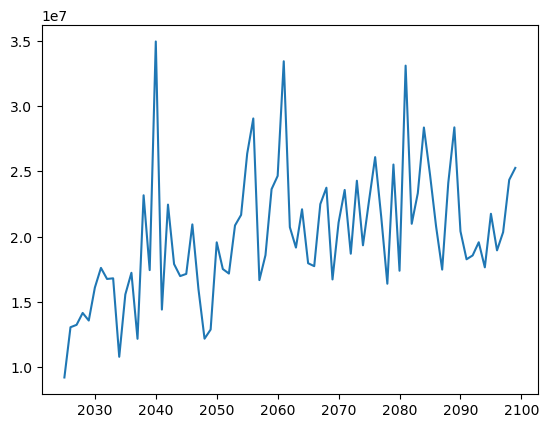

In [41]:
plt.plot(aggregated_world.index, aggregated_world["mean"], label="Moyenne")

## Visualisation - Exemple USA

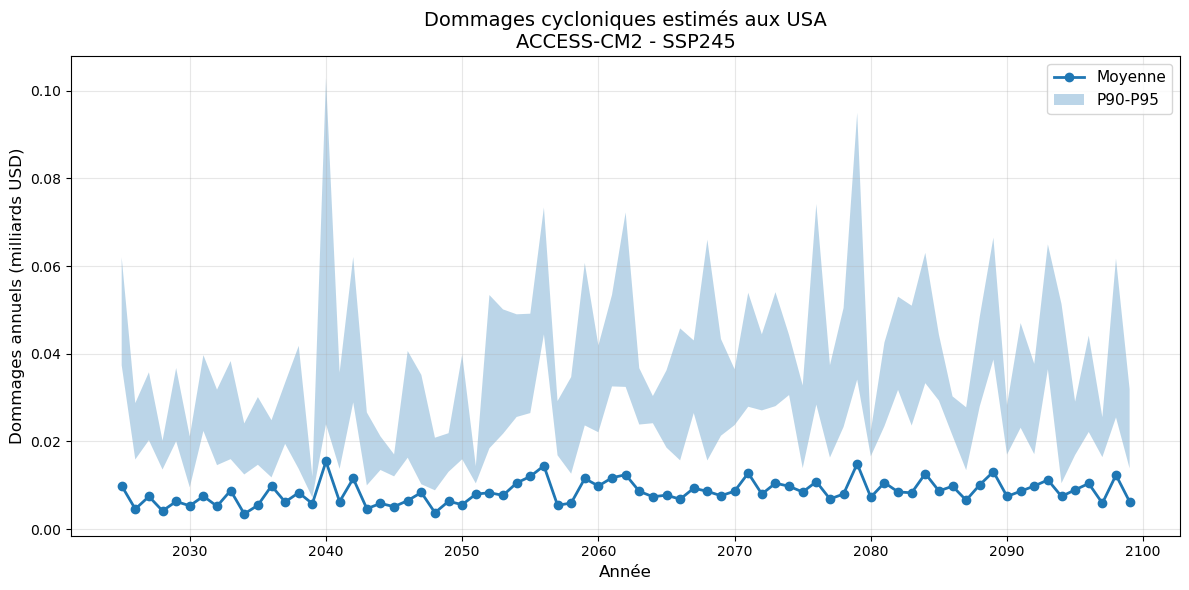


Résumé USA:
  Dommage moyen par année: 0.01 G$
  Dommage max par année: 0.43 G$


In [25]:
# Visualiser les dommages moyens par année pour les USA (si disponible)
usa_stats = statistics[statistics["country_iso2"] == "US"]

if len(usa_stats) > 0:
    fig, ax = plt.subplots(figsize=(12, 6))
    
    ax.plot(
        usa_stats["year"],
        usa_stats["mean"] / 1e9,
        label="Moyenne",
        marker="o",
        linewidth=2,
    )
    ax.fill_between(
        usa_stats["year"],
        usa_stats["p90"] / 1e9,
        usa_stats["p95"] / 1e9,
        alpha=0.3,
        label="P90-P95",
    )
    
    ax.set_xlabel("Année", fontsize=12)
    ax.set_ylabel("Dommages annuels (milliards USD)", fontsize=12)
    ax.set_title(
        f"Dommages cycloniques estimés aux USA\n"
        f"{model} - {experiment.upper()}",
        fontsize=14,
    )
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=11)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nRésumé USA:")
    print(f"  Dommage moyen par année: {usa_stats['mean'].mean() / 1e9:.2f} G$")
    print(f"  Dommage max par année: {usa_stats['max'].max() / 1e9:.2f} G$")
else:
    print("USA non trouvé dans les résultats")

## Résumé des résultats

In [26]:
print("\n" + "="*60)
print("RÉSUMÉ DU CALCUL DES DOMMAGES")
print("="*60)

print(f"\nModèle: {model}")
print(f"Expérience: {experiment}")
print(f"\nRésultats générés:")
print(f"  • Fichiers par pays: {len(output_files)} pays traités")
print(f"  • Données brutes: {all_damages.shape[0]:,} événements")
print(f"  • Données agrégées: {aggregated.shape[0]:,} lignes")
print(f"  • Période: {statistics['year'].min()}-{statistics['year'].max()}")
print(f"\nFichiers de sortie:")
print(f"  • Dommages détaillés: {output_dir / '*.parquet'}")
print(f"  • Agrégation: {agg_file}")
print(f"  • Statistiques: {stats_file}")
print(f"\nTotal dommages (tous pays, tous seeds):")
print(f"  • Somme: {all_damages['absolute_losses'].sum() / 1e12:.2f} T$")
print(f"  • Moyenne par événement: {all_damages['absolute_losses'].mean() / 1e6:.2f} M$")
print("\n" + "="*60)


RÉSUMÉ DU CALCUL DES DOMMAGES

Modèle: ACCESS-CM2
Expérience: ssp245

Résultats générés:
  • Fichiers par pays: 125 pays traités
  • Données brutes: 4,354,829 événements
  • Données agrégées: 137,358 lignes
  • Période: 2025-2099

Fichiers de sortie:
  • Dommages détaillés: data/output/damages/by_country/ACCESS-CM2/ssp245/*.parquet
  • Agrégation: data/output/damages/by_country/ACCESS-CM2/ssp245/damages_aggregated.parquet
  • Statistiques: data/output/damages/by_country/ACCESS-CM2/ssp245/damages_statistics.parquet

Total dommages (tous pays, tous seeds):
  • Somme: 0.15 T$
  • Moyenne par événement: 0.06 M$

